# 1. CSV 파일 불러오기

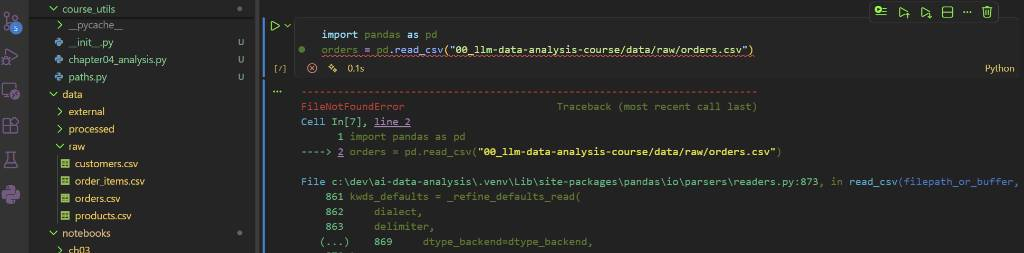
### 경로 문제
데이터 파일이 현재 작업중인 폴더 안에 있지 않기 때문에 경로를 경로를 찾지 못함.  
파일경로를 다 적어도 찾지 못하는 이유는  

컴퓨터가 경로를 해석할 때, 맨 앞에 `/` 나 `C:\` 같은 절대적인 루트 표시가 없으면 항상  
내가 있는 폴더를 맨앞으로 생각하고 탐색을 시작하기 때문  
`"c:/dev/ai-data-analysis/00_llm-data-analysis-course/data/raw/orders.csv" `  
위와 같이 풀로 쓰면 불러와지긴함..

In [4]:
import pandas as pd
orders = pd.read_csv("../../data/raw/orders.csv")
products = pd.read_csv("../../data/raw/products.csv")

In [5]:
# 폴더 위치 확인 하는 명령어
# import os; print(os.getcwd())

customers = pd.read_csv("../../data/raw/customers.csv")
order_items = pd.read_csv("../../data/raw/order_items.csv")
print(customers.info())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  150 non-null    int64
 1   name         150 non-null    str  
 2   gender       150 non-null    str  
 3   age          150 non-null    int64
 4   city         150 non-null    str  
 5   signup_date  150 non-null    str  
dtypes: int64(2), str(4)
memory usage: 11.0 KB
None


In [6]:
customers.shape
# order_items.shape
orders.shape
# products.shape

(301, 5)

In [7]:
customers.head()
# customers.tail()

,customer_id,name,gender,age,city,signup_date
0,1,김수민,F,19,광주,2024-07-16
1,2,김정호,F,32,대구,2025-11-29
2,3,이경수,F,61,성남,2024-07-09
3,4,조영호,F,55,울산,2026-05-10
4,5,이예원,F,19,부산,2024-10-10


In [8]:
customers.columns.tolist()

['customer_id', 'name', 'gender', 'age', 'city', 'signup_date']

In [9]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  150 non-null    int64
 1   name         150 non-null    str  
 2   gender       150 non-null    str  
 3   age          150 non-null    int64
 4   city         150 non-null    str  
 5   signup_date  150 non-null    str  
dtypes: int64(2), str(4)
memory usage: 11.0 KB


In [10]:
customers.dtypes

customer_id    int64
name             str
gender           str
age            int64
city             str
signup_date      str
dtype: object

In [11]:
orders["order_date"].dtype

<StringDtype(na_value=nan)>

In [12]:
print(orders.info())

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   order_id        301 non-null    int64
 1   customer_id     301 non-null    int64
 2   order_date      301 non-null    str  
 3   payment_method  301 non-null    str  
 4   order_status    301 non-null    str  
dtypes: int64(2), str(3)
memory usage: 20.0 KB
None


In [13]:
converted=pd.to_numeric(products["price"], errors="coerce")

### 정리하자면 컴퓨터는 이 코드를 실행할 때 딱 2가지 행동만 합니다.  
1. 숫자로만 된 문자열(예: '1500', '3000') ➡️ 진짜 연산이 가능한 정수나 실수(숫자)로 변환합니다.  
2. 글자가 섞여서 변환이 불가능한 값(예: '1500원', '없음') ➡️ 에러를 내며 멈추는 대신, 깔끔하게 NaN(빈칸) 처리하고 넘어갑니다.  

이렇게 불량 데이터들을 NaN으로 모아두어야, 나중에 "아, 이 NaN 데이터들은 0으로 채워야겠다"라든지 "그냥 삭제해야겠다" 같은 다음 데이터 정제 작업을 수월하게 진행할 수 있습니다.

In [14]:
print(converted)

0     160000
1      34000
2     152000
3      70000
4     186000
       ...  
95    112000
96    154000
97     10000
98    200000
99    102000
Name: price, Length: 100, dtype: int64


In [15]:
converted_data =pd.to_datetime(
    orders["order_date"],
    errors="coerce"
)

print(converted_data)

0     2026-06-03
1     2025-08-19
2     2025-12-16
3     2026-02-26
4     2026-01-17
         ...    
296   2026-02-11
297   2026-01-21
298   2025-09-04
299   2026-03-24
300   2026-01-24
Name: order_date, Length: 301, dtype: datetime64[us]


1. 컴퓨터의 처리 방식  
- 정상적인 날짜 문자열 (예: '2026-03-05', '2026/03/05', '2026.03.05 14:30')  
  ➡️ 컴퓨터가 인지하고 정렬·계산할 수 있는 진짜 날짜형 데이터(datetime64)로 변환합니다.  
날짜로 바꿀 수 없는 이상한 문자열 (예: '2026년쯤', '알 수 없음', '결제오류')  
- ➡️ errors="coerce" 옵션 덕분에 에러로 멈추지 않고, NaT(Not a Time: 날짜 전용 빈칸/결측치)로 변환합니다.

*(참고로 Pandas에서는 숫자형 빈칸을 NaN으로 부르고, 날짜형 빈칸은 Time의 의미를 담아 **NaT*라고 부르지만 똑같은 결측치입니다.)2. 왜 날짜형 데이터로 바꿔야 할까요?문자열 상태에서는 불가능하지만, 진짜 날짜형(datetime64)으로 변환하고 나면 다음과 같은 데이터 분석이 가능해지기 때문입니다.날짜 순서대로 정렬하기 (요일이나 월별로 정렬 가능)기간 계산하기 (배송 완료일 - 주문일 = 배송 걸린 기간)특정 정보만 쏙 쏙 빼오기 (주문일에서 '연도', '월', '일', '요일'만 분리 추출)

In [16]:
before_missing = products["price"].isna().sum()
after_missing = converted.isna().sum()
print(before_missing, after_missing)

0 0


.isna() = 빈칸 (결측치, NaN/NaT)을 찾을 때 사용
.sum() = 더 하는 메서드[.을 붙여서 사용하는 함수]

.isna().sum() = 각 열별로 빈칸이 몇개씩 있는지 보여줌  

1. 함수(Function)와 메서드(Method)의 차이  
- 함수 (Function): 혼자서도 독립적으로 일할 수 있는 명령어입니다.  
    - 예: print(orders), type(orders) 처럼 괄호 안에 대상을 집어넣는 형태입니다.  
- 메서드 (Method): 특정 데이터(객체)에 '종속'되어 있어서, 그 데이터가 있어야만 실행할 수 있는 명령어입니다. "데이터 너 이거 해라!" 하고 명령을 내리는 꼴입니다.   
    - 예: orders.isna(), orders.sum() 처럼 반드시 앞에 데이터.이 붙는 형태입니다.
2. 왜 묶어서 쓸 수 있을까요? (메서드 체이닝)  
`.isna().sum()처럼 메서드를 기차 기차놀이 하듯 줄줄이 이어 붙이는 것을 '메서드 체이닝(Method Chaining)'이라고 부릅니다.`

이게 가능한 이유는 앞의 메서드가 일을 끝내고 돌려준 결과물에, 곧바로 뒤의 메서드가 이어서 명령을 내릴 수 있기 때문입니다.  
1. converted_data ➡️ [날짜 데이터]
2. converted_data.isna() ➡️ 날짜 데이터가 [True/False 데이터]로 변신!
3. converted_data.isna().sum() ➡️ 변신한 True/False 데이터에 대고 .sum() 메서드를 실행하여 [최종 숫자]를 계산!

In [17]:
customers.duplicated().sum()

np.int64(0)

.duplicated() = 완벽하게 똑같이 중복된 불량 데이터가 없는지 확인하는 메서드  
.np = NumPy 라이브러리의 줄임말
    1. 빠른 대용량 숫자 계산
    2. '반복문(for문) 없이' 모든 데이터 일괄 계산
    3. 고차원'행렬(Matrix)'연산과 통계 기능

In [18]:

customers["customer_id"].duplicated().sum()

np.int64(0)

In [19]:
customers["age"].describe()

count    150.000000
mean      42.086667
std       15.613166
min       19.000000
25%       29.000000
50%       40.000000
75%       57.000000
max       69.000000
Name: age, dtype: float64

In [20]:
products["price"].describe()

count       100.000000
mean     110040.000000
std       56433.910574
min        5000.000000
25%       65750.000000
50%      112000.000000
75%      161000.000000
max      200000.000000
Name: price, dtype: float64

.describe() 메서드 = 핵심 요약 통계

- count_개수 : 데이터의 총 개수
- mean_평균 
- std_표준편차 : 변동성. 값이 클수록 차이가 크다는 뜻
    - 값이 크기를 판단하는 기준 = 평균값을 기준으로 삼는 것이 정석
    - 평균 % 표준편차 = 변동성
- min_최솟값 
- 25%_제 1사분위수
- 50%_중앙값
    - 평균과 중앙값이 얼마나 서로 가까이 있는가?
        - 평균 중앙값이 가까울수록 데이터의 신뢰도는 높다
- 75%_제 3사분위수
- max_최대값

In [21]:

orders["order_status"].value_counts(dropna=False)

order_status
completed    184
cancelled     65
refunded      52
Name: count, dtype: int64

In [22]:
order_dates=pd.to_datetime(
    orders["order_date"],
    errors="coerce"

)

In [23]:
print(order_dates.isna().sum())
print(order_dates.min())
print(order_dates.max())

0
2025-08-05 00:00:00
2026-08-04 00:00:00


In [ ]:
checks = {
#검사할 대상들을 모아두는 딕셔너리 변수_ "화면에 출력 할 이름" :실제 검사할 데이터 컬럼
    "customers.customer_id": customers["customer_id"],
    # customers 테이블의 custmomer_id 컴럼을 검사 대상으로 넣은 것
    "products.product_id": products["product_id"],
    "orders.order_id": orders["order_id"],
    "order_items.order_item_id": order_items["order_item_id"],
}

for name, series in checks.items():
    print(
        name,
        "결측:", series.isna().sum(),
        "중복:", series.duplicated().sum(),
        "고유값:", series.nunique()
    )

customers.customer_id 결측: 0 중복: 0 고유값: 150
products.product_id 결측: 0 중복: 0 고유값: 100
orders.order_id 결측: 0 중복: 0 고유값: 301
order_items.order_item_id 결측: 0 중복: 1 고유값: 765
